In [1]:
import numpy as np
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# 可視化ライブラリ
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
sns.set()
%matplotlib inline

# 小数第3位まで
%precision 3

'%.3f'

In [2]:
from sklearn import linear_model

In [7]:
student_data_math = pd.read_csv(
    'student+performance/student/student-mat.csv',
    sep=';'
)

In [8]:
student_data_math.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [9]:
?pd.read_csv

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[HashableT, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: 

In [10]:
# すべてのカラムの情報等をチェック
student_data_math.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [11]:
student_data_math['sex'].head()

0    F
1    F
2    F
3    F
4    F
Name: sex, dtype: str

In [12]:
student_data_math['absences'].head()

0     6
1     4
2    10
3     2
4     4
Name: absences, dtype: int64

In [13]:
student_data_math.groupby('sex')['age'].mean()

sex
F    16.730769
M    16.657754
Name: age, dtype: float64

In [14]:
#Let's try
# 読み込んだデータを使って、いろいろな視点でデータ集計して、データと対話してみましょう。

In [15]:
# 男女別の欠席率の平均
student_data_math.groupby('sex')['absences'].mean()

sex
F    6.216346
M    5.144385
Name: absences, dtype: float64

In [16]:
# 年齢ごとの欠席率の平均
student_data_math.groupby('age')['absences'].mean()

age
15     3.341463
16     5.451923
17     6.459184
18     6.048780
19    10.458333
20     5.000000
21     3.000000
22    16.000000
Name: absences, dtype: float64

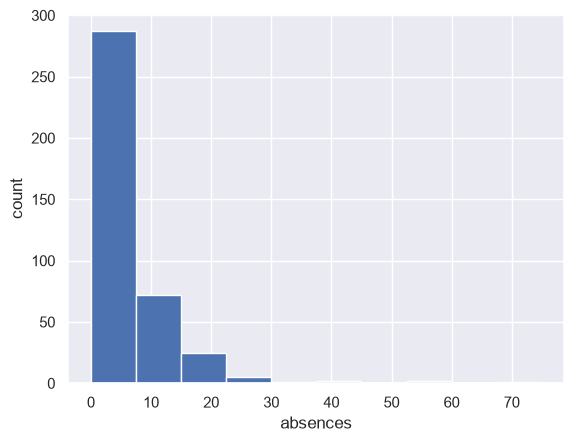

In [17]:
# histogram, データの指定
plt.hist(student_data_math['absences'])

# x軸とy軸のそれぞれのラベル
plt.xlabel('absences')
plt.ylabel('count')

# グリッドをつける
plt.grid(True)

In [18]:
abse = student_data_math['absences']

# 平均値
print('平均値:', abse.mean())
# 中央値
print('中央値:', abse.median())
# 最頻値
print('最頻値:', abse.mode())

平均値: 5.708860759493671
中央値: 4.0
最頻値: 0    0
Name: absences, dtype: int64


In [19]:
# 分散
abse.var(ddof=0)

63.887

In [20]:
# 標準偏差
abse.std(ddof=0)

7.993

In [21]:
np.sqrt(abse.var(ddof=0))

7.993

In [22]:
# 要約統計量
student_data_math['absences'].describe()

count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64

In [25]:
# 四分位範囲
student_data_math['absences'].describe()['75%'] - student_data_math['absences'].describe()['25%']

8.000

In [26]:
student_data_math.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


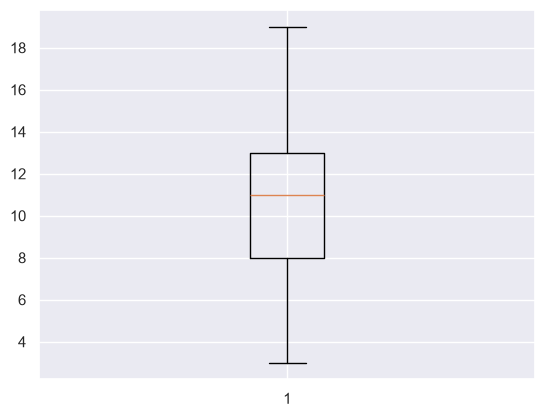

In [27]:
# 箱ひげ図:G1
plt.boxplot(student_data_math['G1'])
plt.grid(True)

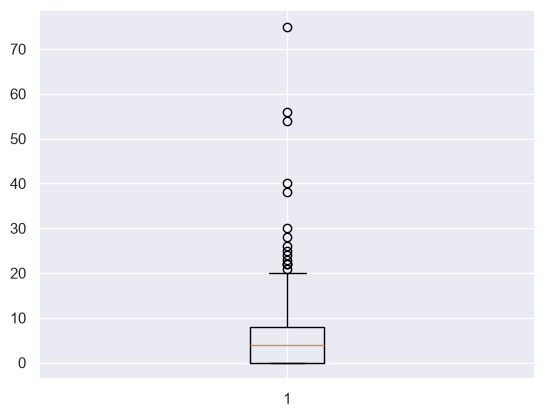

In [28]:
# 箱ひげ図:欠席数
plt.boxplot(student_data_math['absences'])
plt.grid(True)

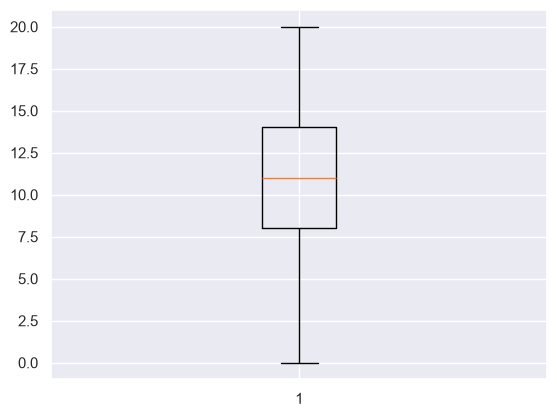

In [29]:
#Let's try
# ほかの変数についても、箱ひげ図を表示
# G3の箱ひげ図
plt.boxplot(student_data_math['G3'])
plt.grid(True)

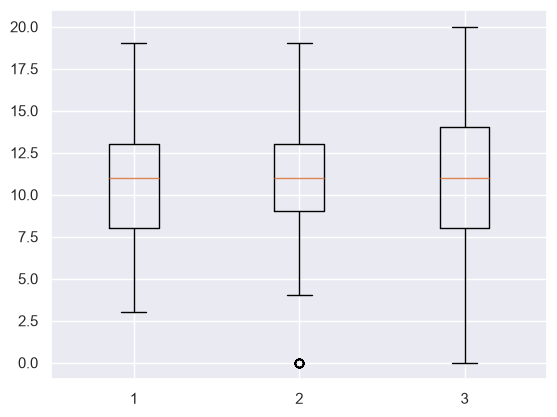

In [30]:
# 箱ひげ図: G1, G2, G3
plt.boxplot([student_data_math['G1'], student_data_math['G2'], student_data_math['G3']])
plt.grid(True)

In [31]:
# 変動係数: 欠席数
student_data_math['absences'].std(ddof=0) / student_data_math['absences'].mean()

1.400

In [35]:
student_data_math.std(ddof=0, numeric_only=True) / student_data_math.mean(numeric_only=True)

age           0.076330
Medu          0.397673
Fedu          0.431019
traveltime    0.481058
studytime     0.411791
failures      2.222501
famrel        0.227042
freetime      0.308334
goout         0.357645
Dalc          0.600679
Walc          0.561409
health        0.390651
absences      1.400097
G1            0.303881
G2            0.350641
G3            0.439324
dtype: float64

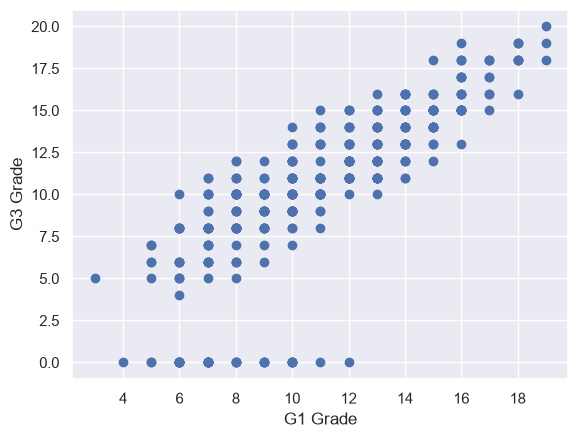

In [38]:
# 散布図
plt.plot(student_data_math['G1'], student_data_math['G3'], 'o')

# ラベル
plt.ylabel('G3 Grade')
plt.xlabel('G1 Grade')
plt.grid(True)

In [40]:
# 共分散行列
np.cov(student_data_math['G1'], student_data_math['G3'], ddof=0)

array([[10.989, 12.157],
       [12.157, 20.936]])

In [41]:
# 分散
print('G1の分散:', student_data_math['G1'].var(ddof=0))
print('G3の分散:', student_data_math['G3'].var(ddof=0))

G1の分散: 10.989161993270308
G3の分散: 20.936478128505044


In [42]:
sp.stats.pearsonr(student_data_math['G1'], student_data_math['G3'])

PearsonRResult(statistic=np.float64(0.8014679320174142), pvalue=np.float64(9.00143031227676e-90))

In [43]:
# 相関行列
np.corrcoef([student_data_math['G1'], student_data_math['G3']])

array([[1.   , 0.801],
       [0.801, 1.   ]])

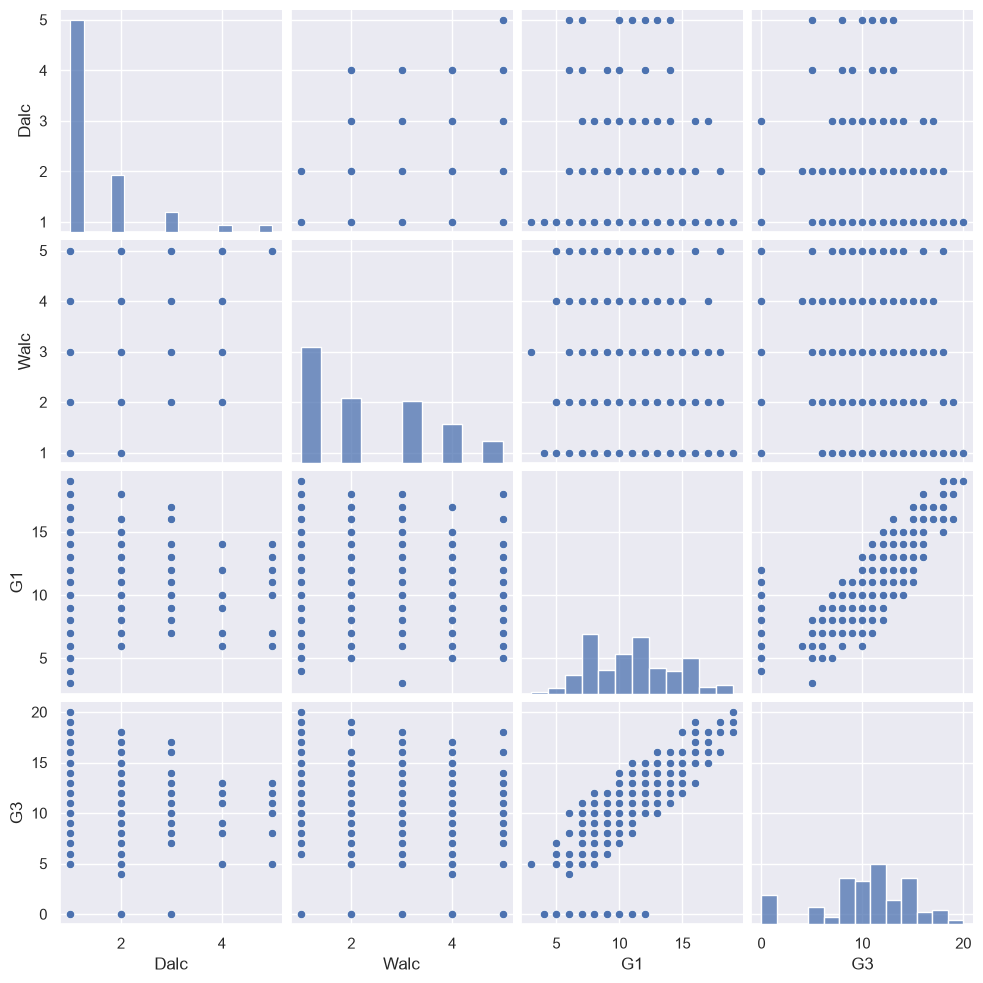

In [45]:
sns.pairplot(student_data_math[['Dalc', 'Walc', 'G1', 'G3']])
plt.grid(True)

In [46]:
# 週末にアルコールを飲む人の1期目の成績の平均値
student_data_math.groupby('Walc')['G1'].mean()

Walc
1    11.178808
2    11.270588
3    10.937500
4     9.980392
5     9.964286
Name: G1, dtype: float64

In [52]:
# 練習問題１ student-por.csvを読み込んで、要約統計量を表示
student_data_por = pd.read_csv('student+performance/student/student-por.csv', sep=';')
student_data_por.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [54]:
# 数学のデータとポルトガル語のデータをマージ
student_data_merge = pd.merge(student_data_math,
                              student_data_por,
                              on = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'nursery', 'internet'],
                              suffixes=('_math', '_por'))
student_data_merge

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
378,MS,F,18,U,GT3,T,1,1,other,other,...,3,4,4,2,2,5,3,7,8,7
379,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
380,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


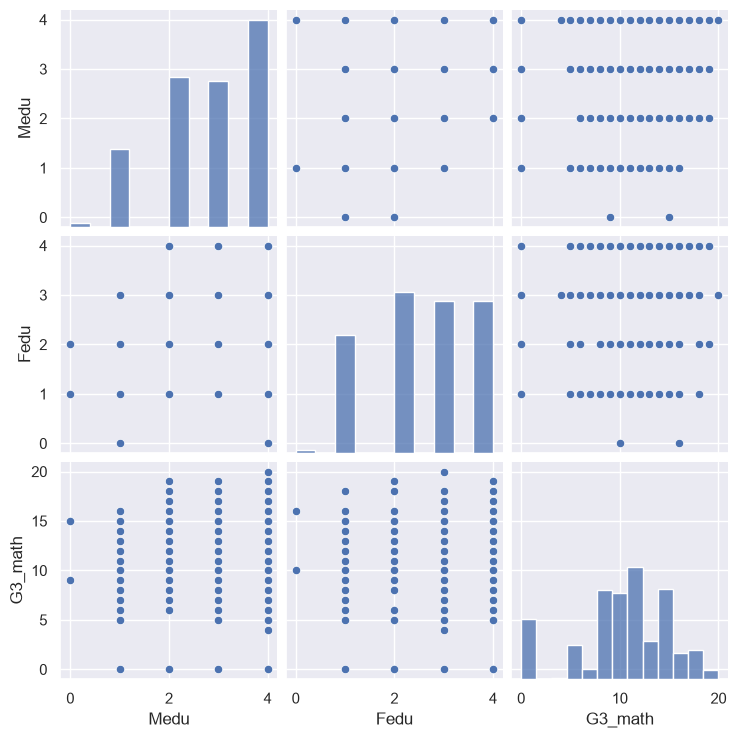

In [56]:
# マージしたデータについて、Medu, Fedu, G3_mathなどの変数をいくつかピックアップして、散布図とヒストグラムの作成
sns.pairplot(student_data_merge[['Medu', 'Fedu', 'G3_math']])
plt.grid(True)

In [57]:
from sklearn import linear_model

# 線形回帰のインスタンスを生成
reg = linear_model.LinearRegression()

In [58]:
# 説明変数に一期目の数学の成績を利用
# locはデータフレームから、行と列を指定して取り出す。 loc[:, ['G1']]は、G1列のすべての行を取り出すことにしている
X = student_data_math.loc[:, ['G1']].values

# 目的変数に最終の数学の成績を利用
Y = student_data_math['G3'].values

# 予測モデルを計算、ここでa,bを算出
reg.fit(X, Y)

# 回帰係数
print('回帰係数:', reg.coef_)

# 切片
print('切片:', reg.intercept_)

回帰係数: [1.106]
切片: -1.6528038288004563


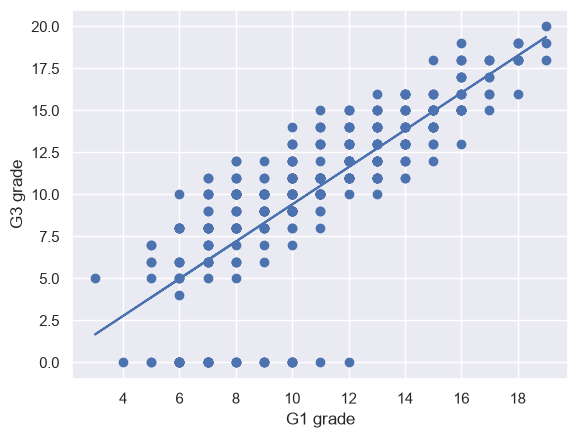

In [61]:
# 先ほどと同じ散布図
plt.scatter(X, Y)
plt.xlabel('G1 grade')
plt.ylabel('G3 grade')

# その上に線形回帰直線を引く
plt.plot(X, reg.predict(X))
plt.grid(True)

In [62]:
# 決定係数、寄与率とも呼ばれる
print('決定係数:', reg.score(X, Y))

決定係数: 0.64235084605227


In [64]:
# 練習問題
# ポルトガル語の成績データであるstudent-por.csvのデータを使って、G3を目的変数、 G1を説明変数として単回帰分析を実施し回帰係数、切片、決定係数を求める
X = student_data_por.loc[:, ['G1']].values

Y = student_data_por['G3'].values

reg.fit(X, Y)
print('回帰係数:', reg.coef_)
print('切片:', reg.intercept_)
print('決定係数:', reg.score(X, Y))

回帰係数: [0.973]
切片: 0.8203984121064529
決定係数: 0.6829156800171083


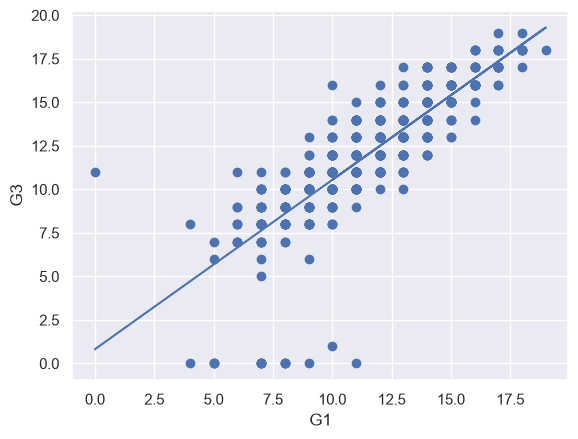

In [65]:
# 練習問題
# データの実際の散布図と回帰直線に合わせてグラフ化
plt.scatter(X, Y)
plt.xlabel('G1')
plt.ylabel('G3')

plt.plot(X, reg.predict(X))

In [66]:
# 練習問題
# student-por.csvのデータを使って、G3を目的変数、absencesを説明変数として単回帰分析を実施、回帰係数、、切片、決定係数を求める。また、散布図と回帰直線をグラフ化
from sklearn import linear_model

# 線形回帰のインスタンスを生成
reg = linear_model.LinearRegression()

# 説明変数に "欠席数" を利用
X = student_data_por.loc[:, ['absences']].values

# 目的変数に "最終の成績" を利用
Y = student_data_por['G3'].values

# 予測モデルを計算
reg.fit(X, Y)

# 回帰係数
print('回帰係数:', reg.coef_)

# 切片
print('切片:', reg.intercept_)

# 決定係数
print('決定係数:', reg.score(X, Y))

回帰係数: [-0.064]
切片: 12.138800862687443
決定係数: 0.008350131955637385


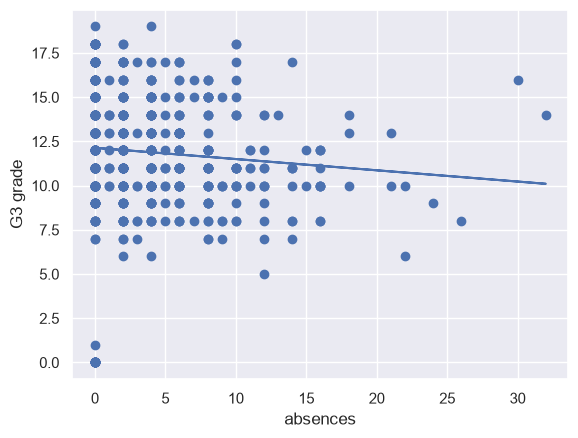

In [67]:
# 散布図
plt.scatter(X, Y)
plt.xlabel('absences')
plt.ylabel('G3 grade')

# その上に線形回帰直線を引く
plt.plot(X, reg.predict(X))
plt.grid(True)